In [2]:
# Disable JAXFEM logging
import jax_fem                       # forces setup_logger() to run NOW
import logging
jl = logging.getLogger('jax_fem')
jl.setLevel(logging.WARNING)         # or logging.ERROR to also silence INFO
jl.handlers.clear()                  # remove jax_fem's own StreamHandler
jl.propagate = False


from optimization import (
    load_eq, 
    run_filament_free, 
    increase_base_curve_order
)

from coilforce.support import CoilSupportDiscrete, CoilSupportTopBottom
from coilforce.simsopt_bridge import CoilFEMObjective

# Loading config from simsopt
from simsopt import load, save
from simsopt.configs import get_data
from simsopt.geo import plot, CurveLength
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
    RegularizedCoil, LpCurveForce,
)
from simsopt.objectives import SquaredFlux
# Import mesh and material properties
from optimization import (
    mesh_options,
    problem_options,
    material_options_const_temp,
    material_options_variable_temp,
)

import matplotlib.pyplot as plt


eq, Bnormal_plasma, plasma_surface_vc, vc = load_eq('wout.nc')
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=10, points_per_period=4)
coils_w7x = coils_via_symmetries(curves[:5], currents[:5], nfp, True)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [3]:
coils_support = load('coils_support.json') # Corresponds to case (A)
coils_fixed = load('coils_fixed.json')     # Corresponds to case (B)
coils_movable = load('coils_movable.json') # Corresponds to case (C)
coils_force = load('coils_force.json')     # Corresponds to case (D)

In [4]:
Jstress_w7x = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_w7x[:5]],
    base_currents    = [c.current for c in coils_w7x[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_force = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_force[:5]],
    base_currents    = [c.current for c in coils_force[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_fixed = load('Jstress_fixed.json')[0]
Jstress_movable = load('Jstress_movable.json')[0]
Jstress_support = load('Jstress_support.json')[0]

In [49]:
Jstress_support.x

array([     -0.0821 ,       0.53352,       0.00005,       0.511  ,      -0.00002,       0.51859,       0.01116,       0.63192,      -0.02045,       0.56815, 1620000.     ])

In [52]:
print('Num. dofs force:  ', Jstress_force.x.size)
print('Num. dofs fixed:  ', Jstress_fixed.x.size)
print('Num. dofs movable:', Jstress_movable.x.size)
print('Num. dofs support:', Jstress_support.x.size)

Num. dofs force:   316
Num. dofs fixed:   316
Num. dofs movable: 326
Num. dofs support: 11


In [47]:
len(Jstress_w7x.fem.base_curves_jax[0].quadpoints)

40

## Performing FEM calculations

In [5]:
result_w7x   = Jstress_w7x.run()
result_fixed = Jstress_fixed.run()
result_force = Jstress_force.run()
result_movable = Jstress_movable.run()
result_support = Jstress_support.run()

solving with float64


In [56]:
result_w7x['von_mises']

[Array([[1.72810e+08, 1.81772e+08, 1.26068e+08, 1.64004e+08],
        [1.68148e+08, 1.19279e+08, 1.40133e+08, 1.69894e+08],
        [9.46580e+07, 1.16150e+08, 1.03043e+08, 1.52403e+08],
        [1.81119e+08, 1.84586e+08, 1.25261e+08, 1.64397e+08],
        [1.48654e+08, 1.06392e+08, 8.67881e+07, 1.55639e+08],
        [9.38628e+07, 9.96995e+07, 9.88581e+07, 1.62117e+08],
        [1.03506e+08, 7.28790e+07, 4.95944e+07, 8.73959e+07],
        [6.54955e+07, 3.84077e+07, 4.43803e+07, 9.30579e+07],
        [4.72375e+07, 3.26107e+07, 4.84014e+07, 4.17787e+07],
        [6.05679e+07, 6.09344e+07, 3.40456e+07, 7.39838e+07],
        [4.52055e+07, 2.91277e+07, 3.09598e+07, 4.64003e+07],
        [4.60270e+07, 6.27512e+07, 5.74254e+07, 2.44092e+07],
        [1.81039e+08, 1.64068e+08, 9.62593e+07, 1.85672e+08],
        [1.47387e+08, 1.09158e+08, 1.15247e+08, 1.83536e+08],
        [8.84489e+07, 8.79073e+07, 9.12291e+07, 1.23162e+08],
        [1.53702e+08, 1.76300e+08, 1.33143e+08, 1.79280e+08],
        

## Performing force calculations

In [6]:
import numpy as np
coil_per_half_fp = 5
def calculate_forces(coils, full=False):
    if full:
        i = len(coils)
    else:
        i = coil_per_half_fp
    force_coils = [RegularizedCoil(c.curve, c.current, 0.7) for c in coils]
    Jf = LpCurveForce(
        target_coils=force_coils[:coil_per_half_fp],
        source_coils_coarse=force_coils,
    )
    forces_vec = [c.force(force_coils) for c in force_coils][:i]
    forces = [np.linalg.norm(c.force(force_coils), axis=-1) for c in force_coils][:i]
    gammas = [c.curve.gamma() for c in coils][:i]
    arclens = [np.linalg.norm(c.curve.gammadash(), axis=1) for c in coils][:i]
    lens = [CurveLength(c.curve).J() for c in coils][:i]
    return forces_vec, forces, gammas, arclens, lens, Jf

def calc_bnormal(coils, plasma_surface, Bnormal_plasma):
    bs = BiotSavart(coils)
    gamma_shape = plasma_surface.gamma().shape
    bs.set_points(plasma_surface.gamma().reshape((-1, 3)))
    B_normal = np.sum(bs.B().reshape(gamma_shape) * plasma_surface.unitnormal(), axis=-1)
    Jf_norm = SquaredFlux(
        plasma_surface,
        bs,
        target=Bnormal_plasma,
        definition='normalized',
    )
    return B_normal, bs, Jf_norm

def pct_change(before, after):
    return round((after - before)/before*100, 1)

In [7]:
(
    forces_vec_fixed, 
    forces_fixed, 
    gamma_fixed, 
    arclens_fixed, 
    lens_fixed, 
    Jf_fixed
) = calculate_forces(coils_fixed)
(
    forces_vec_movable, 
    forces_movable, 
    gamma_movable, 
    arclens_movable, 
    lens_movable, 
    Jf_movable
) = calculate_forces(coils_movable)
(
    forces_vec_force, 
    forces_force, 
    gamma_force, 
    arclens_force, 
    lens_force, 
    Jf_force
) = calculate_forces(coils_force)
(
    forces_vec_w7x, 
    forces_w7x, 
    gamma_w7x, 
    arclens_w7x, 
    lens_w7x, 
    Jf_w7x
) = calculate_forces(coils_w7x)
(
    forces_vec_support, 
    forces_support, 
    gamma_support, 
    arclens_support, 
    lens_support, 
    Jf_support
) = calculate_forces(coils_support)
(B_normal_fixed  , bs_fixed  , Jf_norm_fixed  ) = calc_bnormal(coils_fixed,   plasma_surface_vc, Bnormal_plasma)
(B_normal_movable, bs_movable, Jf_norm_movable) = calc_bnormal(coils_movable, plasma_surface_vc, Bnormal_plasma)
(B_normal_force  , bs_force  , Jf_norm_force  ) = calc_bnormal(coils_force,   plasma_surface_vc, Bnormal_plasma)
(B_normal_w7x    , bs_w7x    , Jf_norm_w7x    ) = calc_bnormal(coils_w7x,     plasma_surface_vc, Bnormal_plasma)
(B_normal_support, bs_support, Jf_norm_support) = calc_bnormal(coils_support, plasma_surface_vc, Bnormal_plasma)
maxabs = lambda x: np.max(np.abs(x))
RMS = lambda x, arclens: np.sqrt(np.sum(np.array(x)**2 * arclens) / np.sum(arclens))
max_force_fixed   = maxabs(forces_fixed)
max_force_movable = maxabs(forces_movable)
max_force_force   = maxabs(forces_force)
max_force_w7x     = maxabs(forces_w7x)
max_force_support = maxabs(forces_support)
RMS_force_fixed   = RMS(forces_fixed, arclens_fixed)
RMS_force_movable = RMS(forces_movable, arclens_movable)
RMS_force_force   = RMS(forces_force, arclens_force)
RMS_force_w7x     = RMS(forces_w7x, arclens_w7x)
RMS_force_support = RMS(forces_support, arclens_support)
Jstress_val_fixed   = Jstress_fixed.J()
Jstress_val_movable = Jstress_movable.J()
Jstress_val_force   = Jstress_force.J()
Jstress_val_w7x     = Jstress_w7x.J()
Jstress_val_support = Jstress_support.J()
Jf_norm_val_fixed   = Jf_norm_fixed.J()
Jf_norm_val_movable = Jf_norm_movable.J()
Jf_norm_val_force   = Jf_norm_force.J()
Jf_norm_val_w7x     = Jf_norm_w7x.J()
Jf_norm_val_support = Jf_norm_support.J()
print('L2 von mises     w7x', Jstress_val_w7x)
print('L2 von mises   fixed', Jstress_val_fixed,   'change (%)', pct_change(Jstress_val_w7x, Jstress_val_fixed))
print('L2 von mises movable', Jstress_val_movable, 'change (%)', pct_change(Jstress_val_w7x, Jstress_val_movable))
print('L2 von mises   force', Jstress_val_force,   'change (%)', pct_change(Jstress_val_w7x, Jstress_val_force))
print('L2 von mises support', Jstress_val_support, 'change (%)', pct_change(Jstress_val_w7x, Jstress_val_support))
print('Forces     w7x - max:', max_force_w7x)
print('Forces   fixed - max:', max_force_fixed,   'change (%)', pct_change(max_force_w7x, max_force_fixed))
print('Forces movable - max:', max_force_movable, 'change (%)', pct_change(max_force_w7x, max_force_movable))
print('Forces   force - max:', max_force_force,   'change (%)', pct_change(max_force_w7x, max_force_force))
print('Forces support - max:', max_force_support, 'change (%)', pct_change(max_force_w7x, max_force_support))
print('Forces     w7x - RMS:', RMS_force_w7x)
print('Forces   fixed - RMS:', RMS_force_fixed,   'change (%)', pct_change(RMS_force_w7x, RMS_force_fixed))
print('Forces movable - RMS:', RMS_force_movable, 'change (%)', pct_change(RMS_force_w7x, RMS_force_movable))
print('Forces   force - RMS:', RMS_force_force,   'change (%)', pct_change(RMS_force_w7x, RMS_force_force))
print('Forces support - RMS:', RMS_force_support, 'change (%)', pct_change(RMS_force_w7x, RMS_force_support))
print('Normalized squared flux     w7x:', Jf_norm_val_w7x)
print('Normalized squared flux   fixed:', Jf_norm_val_fixed, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_fixed))
print('Normalized squared flux movable:', Jf_norm_val_movable, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_movable))
print('Normalized squared flux   force:', Jf_norm_val_force, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_force))
print('Normalized squared flux support:', Jf_norm_val_support, 'change (%)', pct_change(Jf_norm_val_w7x, Jf_norm_val_support))

L2 von mises     w7x 2.0582205567002784e+17
L2 von mises   fixed 1.9293672709322525e+17 change (%) -6.3
L2 von mises movable 3.843307639258766e+16 change (%) -81.3
L2 von mises   force 1.882404431335959e+17 change (%) -8.5
L2 von mises support 5.594844822201933e+16 change (%) -72.8
Forces     w7x - max: 3532974.063967581
Forces   fixed - max: 3571686.0414776555 change (%) 1.1
Forces movable - max: 3553536.621913263 change (%) 0.6
Forces   force - max: 3446521.0824042847 change (%) -2.4
Forces support - max: 3532974.063965831 change (%) -0.0
Forces     w7x - RMS: 1898558.1117223531
Forces   fixed - RMS: 1895641.9778256498 change (%) -0.2
Forces movable - RMS: 1893720.7926093368 change (%) -0.3
Forces   force - RMS: 1882190.010066025 change (%) -0.9
Forces support - RMS: 1898558.1117214123 change (%) -0.0
Normalized squared flux     w7x: 5.435032925907494e-07
Normalized squared flux   fixed: 8.035902216911757e-07 change (%) 47.9
Normalized squared flux movable: 8.662957205561604e-07 chan

(<Figure size 640x480 with 2 Axes>,
 <Axes3D: xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>)

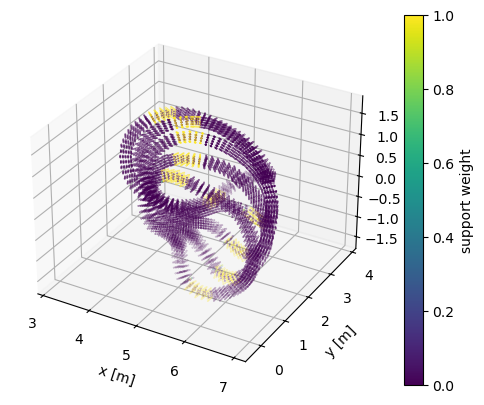

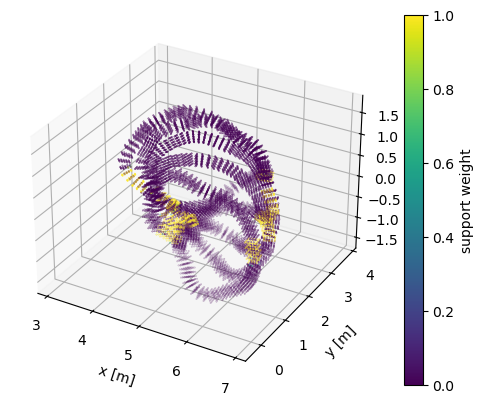

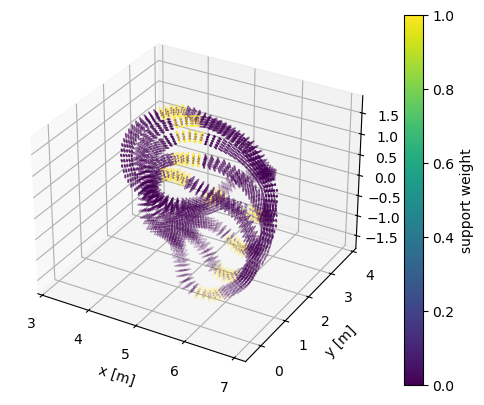

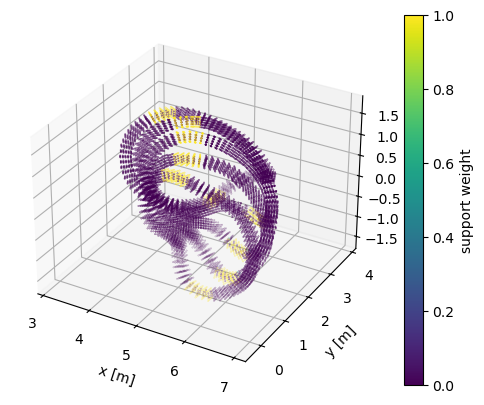

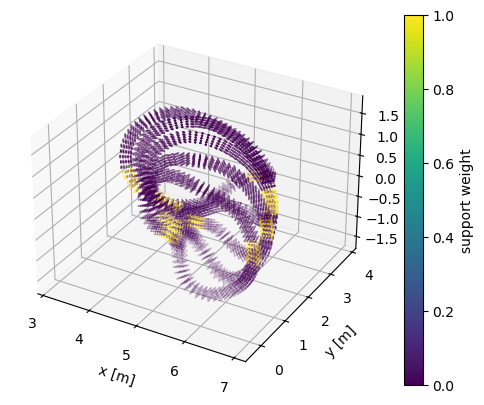

In [8]:
Jstress_fixed.plot_support()
Jstress_movable.plot_support()
Jstress_force.plot_support()
Jstress_w7x.plot_support()
Jstress_support.plot_support()

In [9]:
def calc_obj(name, base_curves, base_currents):
    Jstress = CoilFEMObjective(
        base_curves      = base_curves,
        base_currents    = base_currents,
        base_supports    = [support_type(**support_kwargs)
                            for _ in base_curves],
        metrics          = (name,),
        metric_weights   = (1.,),
        nfp              = plasma_surface.nfp,
        stellsym         = plasma_surface.stellsym,
        mesh_options     = mesh_options,
        material_options = material_options_const_temp,
        problem_options  = problem_options,
    )
    return Jstress.J()

In [10]:
result_force.keys()

dict_keys(['solutions', 'displacements', 'von_mises', 'mesh_points', 'support_weights', 'f_vol', 'B_self', 'B_ext'])

In [11]:
result_w7x['von_mises'][0].shape

(960, 4)

In [12]:
displacements_w7x = [np.linalg.norm(d, axis=-1) for d in result_w7x['displacements']]
displacements_fixed = [np.linalg.norm(d, axis=-1) for d in result_fixed['displacements']]
displacements_force = [np.linalg.norm(d, axis=-1) for d in result_force['displacements']]
displacements_everything = np.array([
    displacements_w7x,
    displacements_fixed,
    displacements_force,
])
vm_w7x = result_w7x['von_mises']
vm_fixed = result_fixed['von_mises']
vm_force = result_force['von_mises']
vm_everything = np.array([
    vm_w7x,
    vm_fixed,
    vm_force,
])

In [13]:
# Quadrature-weighted summary metrics for all 5 cases
# Integrals use the FEM scheme's quadrature weights (JxW), so cell- and
# node-based fields are weighted by element volume exactly as the solver does.
from coilforce.elasticity import recompute_fe_geometry
from coilforce.fem_objectives import total_strain_energy


def volume_weighted_summary(obj, result):
    """RMS/max displacement, RMS/max von Mises, and total strain energy.

    von Mises and the body-force magnitude are ``(n_cells, n_quads)`` quadrature
    fields, weighted directly by JxW.  Displacement magnitude is a nodal field
    interpolated to the quadrature points with the element shape functions before
    weighting.  Maxima are taken over the raw (unsmoothed) quantities.
    """
    fem = obj.fem
    lam, mu = fem._lam, fem._mu
    num_d2 = num_vm2 = num_f2 = vol = 0.0
    max_d = max_vm = max_f = 0.0
    strain_energy = 0.0
    for i in range(len(result['von_mises'])):
        prob = fem._problems[i]
        pts  = result['mesh_points'][i]
        sg, jxw_j, _, _ = recompute_fe_geometry(
            pts, prob._cells_jnp, prob._sg_ref, prob._sv, prob._qw)
        jxw   = np.asarray(jxw_j)               # (n_cells, n_quads)
        sv    = np.asarray(prob._sv)            # (n_quads, n_cell_nodes)
        cells = np.asarray(prob._cells_jnp)     # (n_cells, n_cell_nodes)

        # von Mises: quadrature field -> weight by JxW directly
        vm = np.asarray(result['von_mises'][i])
        num_vm2 += np.sum(vm**2 * jxw)
        max_vm   = max(max_vm, float(np.max(vm)))

        # |u|: nodal field -> interpolate to quadrature points, then weight
        dmag   = np.linalg.norm(np.asarray(result['displacements'][i]), axis=-1)
        dmag_q = np.einsum('qn,cn->cq', sv, dmag[cells])
        num_d2 += np.sum(dmag_q**2 * jxw)
        max_d   = max(max_d, float(np.max(dmag)))

        # body force: quadrature field magnitude -> weight by JxW directly
        fmag = np.linalg.norm(np.asarray(result['f_vol'][i]), axis=-1)
        num_f2 += np.sum(fmag**2 * jxw)
        max_f   = max(max_f, float(np.max(fmag)))

        vol += np.sum(jxw)
        strain_energy += float(total_strain_energy(
            prob, result['solutions'][i], lam, mu, shape_grads=sg, JxW=jxw_j))
    return {
        'rms_displacement_m': float(np.sqrt(num_d2 / vol)),
        'max_displacement_m': max_d,
        'rms_von_mises_Pa':   float(np.sqrt(num_vm2 / vol)),
        'max_von_mises_Pa':   max_vm,
        'rms_body_force_Npm3': float(np.sqrt(num_f2 / vol)),
        'max_body_force_Npm3': max_f,
        'strain_energy_J':    strain_energy,
    }


cases = {
    'w7x':     (Jstress_w7x,     result_w7x),
    'fixed':   (Jstress_fixed,   result_fixed),
    'movable': (Jstress_movable, result_movable),
    'force':   (Jstress_force,   result_force),
    'support': (Jstress_support, result_support),
}

print(f"{'case':8s} {'RMS|u| (m)':>12s} {'max|u| (m)':>12s} "
      f"{'RMS vm (MPa)':>13s} {'max vm (MPa)':>13s} "
      f"{'RMS f (MN/m3)':>14s} {'max f (MN/m3)':>14s} {'U (J)':>12s}")
for name, (obj, res) in cases.items():
    s = volume_weighted_summary(obj, res)
    print(f"{name:8s} {s['rms_displacement_m']:12.4e} {s['max_displacement_m']:12.4e} "
          f"{s['rms_von_mises_Pa']/1e6:13.4f} {s['max_von_mises_Pa']/1e6:13.4f} "
          f"{s['rms_body_force_Npm3']/1e6:14.4e} {s['max_body_force_Npm3']/1e6:14.4e} "
          f"{s['strain_energy_J']:12.4e}")

case       RMS|u| (m)   max|u| (m)  RMS vm (MPa)  max vm (MPa)  RMS f (MN/m3)  max f (MN/m3)        U (J)
w7x        2.4704e-02   6.9787e-02      351.0902     1411.4884     1.0093e+02     1.9879e+02   4.9461e+05
fixed      2.3643e-02   6.7446e-02      340.2905     1379.3121     1.0087e+02     1.9823e+02   4.6427e+05
movable    8.1522e-03   2.2076e-02      153.2584     1124.3603     1.0105e+02     2.0125e+02   9.3762e+04
force      2.2839e-02   6.5121e-02      337.9894     1367.0456     1.0072e+02     1.9801e+02   4.5324e+05
support    1.2097e-02   5.0251e-02      183.0488     1479.3054     1.0093e+02     1.9879e+02   1.3606e+05


In [14]:
# run time statistics
misc_fixed = np.load('misc_fixed.npy', allow_pickle=True).item()
misc_movable = np.load('misc_movable.npy', allow_pickle=True).item()
misc_force = np.load('misc_force.npy', allow_pickle=True).item()
misc_support = np.load('misc_support.npy', allow_pickle=True).item()

In [ ]:
h_fixed   = misc_fixed['time']   % 3600
h_movable = misc_movable['time'] % 3600
h_force   = misc_force['time']   % 3600
h_support = misc_support['time'] % 3600
m_fixed   = (misc_fixed['time']   - h_fixed   * 3600) % 60
m_movable = (misc_movable['time'] - h_movable * 3600) % 60
m_force   = (misc_force['time']   - h_force   * 3600) % 60
m_support = (misc_support['time'] - h_support * 3600) % 60
s_fixed   = (misc_fixed['time']   - h_fixed   * 3600 - m_fixed   * 60)
s_movable = (misc_movable['time'] - h_movable * 3600 - m_movable * 60)
s_force   = (misc_force['time']   - h_force   * 3600 - m_force   * 60)
s_support = (misc_support['time'] - h_support * 3600 - m_support * 60)
print('total time fixed:  ', '$', h_fixed,   r'\text{ h }', m_fixed,   r'\text{ m }', s_fixed,   r'\text{ s}$')
print('total time movable:', '$', h_movable, r'\text{ h }', m_movable, r'\text{ m }', s_movable, r'\text{ s}$')
print('total time force:  ', '$', h_force,   r'\text{ h }', m_force,   r'\text{ m }', s_force,   r'\text{ s}$')
print('total time support:', '$', h_support, r'\text{ h }', m_support, r'\text{ m }', s_support, r'\text{ s}$')

In [15]:
# The nfev was read from the log files.
print('fev time fixed:  ', misc_fixed['time']   / misc_fixed['nfev'])
print('fev time movable:', misc_movable['time'] / misc_movable['nfev'])
print('fev time force:  ', misc_force['time']   / misc_force['nfev'])
print('fev time support:', misc_support['time'] / misc_support['nfev'])

fev time fixed:   10.045177587681572
fev time movable: 9.236312775201695
fev time force:   0.2614042500103627
fev time support: 10.515618068330427


In [29]:
# Comparison bar graphs across all 5 cases: four separate vertical bar charts
import matplotlib.pyplot as plt

case_names = ['w7x', 'support', 'fixed', 'movable', 'force']
# ticks = ['Init', 'Case A\n(fixed coils)', 'Case B\n(fixed support)', 'Case C\n(both optimized)', 'Case D\n(force)']
ticks = ['Init', 'Case A', 'Case B', 'Case C', 'Case D']

# Volume-weighted summary metrics for each case
summary_by_case = {name: volume_weighted_summary(obj, res)
                   for name, (obj, res) in cases.items()}

Jf_norm_by_case = {
    'w7x':     Jf_norm_val_w7x,
    'fixed':   Jf_norm_val_fixed,
    'movable': Jf_norm_val_movable,
    'force':   Jf_norm_val_force,
    'support': Jf_norm_val_support,
}

bar_metrics = [
    (r'$J_{f,\,norm}$',              [Jf_norm_by_case[n] for n in case_names]),
    (r'RMS $\mathbf{F}_{body}$ (MN/m$^3$)',    [summary_by_case[n]['rms_body_force_Npm3'] / 1e6 for n in case_names]),
    (r'RMS $\sigma_v$ (MPa)',   [summary_by_case[n]['rms_von_mises_Pa'] / 1e6 for n in case_names]),
    (r'RMS $\mathbf{u}$ (cm)',         [summary_by_case[n]['rms_displacement_m'] * 100 for n in case_names]),
]

# bar_metrics = [
#     (r'$J_{f,\,norm}$',              [Jf_norm_by_case[n] for n in case_names]),
#     (r'RMS body force $\mathbf{F}_{body}$ (MN/m$^3$)',    [summary_by_case[n]['rms_body_force_Npm3'] / 1e6 for n in case_names]),
#     (r'RMS von Mises stress $\sigma_v$ (MPa)',   [summary_by_case[n]['rms_von_mises_Pa'] / 1e6 for n in case_names]),
#     (r'RMS displacement $\mathbf{u}$ (cm)',         [summary_by_case[n]['rms_displacement_m'] * 100 for n in case_names]),
# ]

bar_colors = plt.cm.tab10(np.arange(len(case_names)))

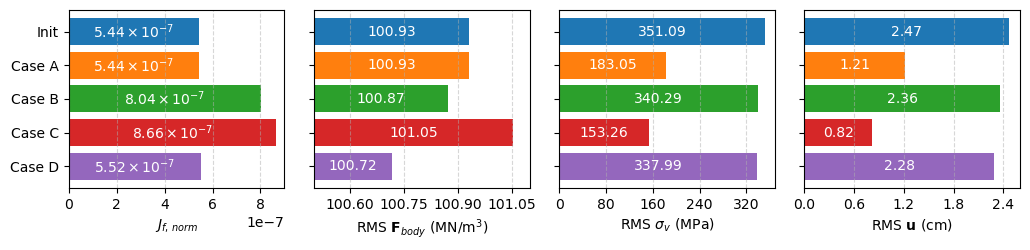

In [36]:
from matplotlib.ticker import MaxNLocator

# Same four metrics as horizontal bars sharing the y axis (case name).
# Only the left-most subplot keeps the case labels to save space.
y = np.arange(len(case_names))


def scix(v, x, b):
    """Format a value to 3 significant figures as n x 10^m."""
    if not b:
        return round(v, x)
    if v == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(v))))
    mant = v / 10.0 ** exp
    return rf"${round(mant, x)}\times10^{{{exp}}}$"


xlims = [
    (None, 9e-7),
    (100.5, 101.1),
    (None, None),
    (None, 2.6),
]
dec_list = [2, 2, 2, 2,]
b_list = [True, False, False, False] # Whether to scientifically format numbers
nticks_list = [5, 5, 5, 5]
width = 2.6
fig, axes = plt.subplots(1, 4, figsize=(width*4, width), sharey=True)
for ax, (title, vals), (x1, x2), dec, b, nticks in zip(axes, bar_metrics, xlims, dec_list, b_list, nticks_list):
    bars = ax.barh(y, vals, color=bar_colors)
    ax.set_xlabel(title)
    ax.set_xlim(x1, x2)
    ax.grid(True, axis='x', linestyle="--", alpha=0.5)
    ax.bar_label(bars, labels=[scix(v, dec, b) for v in vals], color="white", padding=0, label_type='center')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=nticks))

axes[0].set_yticks(y)
axes[0].set_yticklabels(ticks)
axes[0].invert_yaxis()  # w7x at the top
fig.tight_layout()
plt.savefig('../figures/opt-overview.pdf')
plt.show()